# **Perceptron**
Diana Fernanda Barbosa Dueñas

756920

Ingeniería financiera

26/marzo/2026

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Heart Prediction Quantum Dataset.csv to Heart Prediction Quantum Dataset.csv


**EDA**

In [2]:
from sklearn.neural_network import MLPClassifier

In [3]:
import pandas as pd
Heart = pd.read_csv('Heart Prediction Quantum Dataset.csv')
Heart.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [4]:
Heart.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


In [5]:
x = Heart.drop('HeartDisease', axis = 1)
y = Heart['HeartDisease']

In [6]:
Heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [7]:
matriz = Heart.corr()
matriz

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
Age,1.000000,-0.017147,0.031548,-0.014161,0.023712,-0.378599,0.258298
Gender,-0.017147,1.000000,-0.039109,0.025246,-0.010883,0.010276,-0.011454
BloodPressure,0.031548,-0.039109,1.000000,-0.037793,-0.070828,0.105652,-0.116973
Cholesterol,-0.014161,0.025246,-0.037793,1.000000,0.014156,0.549047,-0.423530
HeartRate,0.023712,-0.010883,-0.070828,0.014156,1.000000,0.113533,-0.102720
QuantumPatternFeature,-0.378599,0.010276,0.105652,0.549047,0.113533,1.000000,-0.775160
HeartDisease,0.258298,-0.011454,-0.116973,-0.423530,-0.102720,-0.775160,1.000000


**Histogramas**

In [8]:
col = (["Age"], ["Gender"], ["BloodPressure"], ["Cholesterol"], ["HeartRate"], ["QuantumPatternFeature"], ["HeartDisease"] )

- edad (int) años
- genero (categórico)
- presión sanguínea (int) mmHg
- ritmo cardiaco (int) bmp
- colesterol (int) mig/dl
-enfermedad (bool)

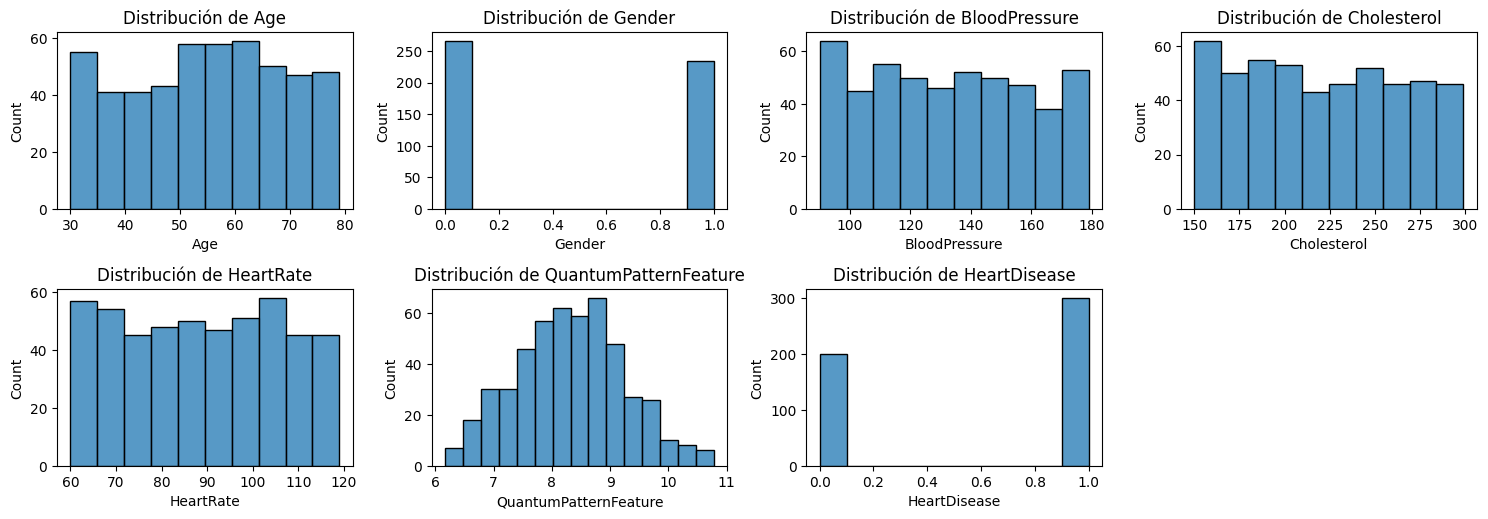

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column_list in enumerate(col):
    column = column_list[0]
    plt.subplot(4, 4, i + 1)
    sns.histplot(Heart[column], kde=False)
    plt.title(f'Distribución de {column}')
plt.tight_layout()
plt.show()

### **Escalamiento**
Definir nuetros "x" y "y" para poder clisificar nuestras columnas si es que necesitan estar en booleanos o no

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

x_features = Heart.drop('HeartDisease', axis = 1)
y = Heart['HeartDisease']

numerical_cols = [col for col in x_features.columns if col != 'Gender']
categorical_cols = ['Gender']

x_num = x_features[numerical_cols]
x_cat = x_features[categorical_cols]

std_scaler = StandardScaler()
x_num_scaled = std_scaler.fit_transform(x_num)
x_num_scaled = pd.DataFrame(x_num_scaled, columns=numerical_cols, index=x_num.index)

x_cat_encoded = pd.get_dummies(x_cat, columns=categorical_cols, drop_first=True)

x = pd.concat([x_num_scaled, x_cat_encoded], axis=1)

**Pipeline**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
hidden_layer_sizes = (5,10)

In [17]:
model = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes,
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)
model

MLPClassifier(hidden_layer_sizes=(5, 10), max_iter=1000, random_state=42)

In [18]:
model.score(X_test, y_test)

0.95

**Cross_val_Score**

In [ ]:
from sklearn.model_selection import cross_val_score

                precision    recall  f1-score   support

Sin enfermedad       0.89      1.00      0.94        40
Con enfermedad       1.00      0.92      0.96        60

      accuracy                           0.95       100
     macro avg       0.94      0.96      0.95       100
  weighted avg       0.96      0.95      0.95       100



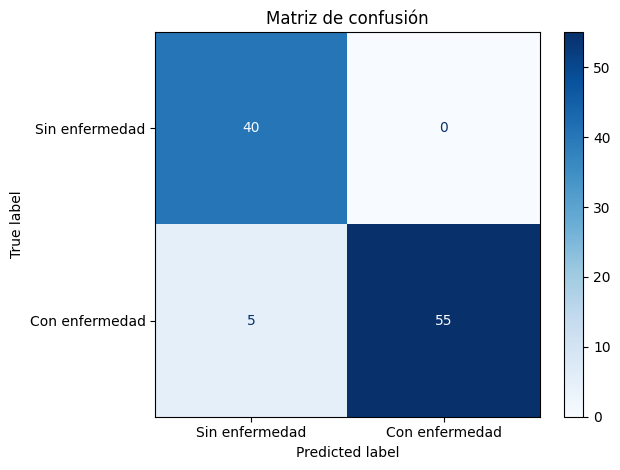

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Sin enfermedad", "Con enfermedad"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sin enfermedad", "Con enfermedad"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

## **Conclusiones**


Se implementó un Perceptrón Multicapa (MLPClassifier) con arquitectura (5, 10)
para clasificar enfermedades cardíacas sobre un dataset de 500 pacientes.

Tras escalar las variables numéricas y codificar el género, el modelo alcanzó
un accuracy del **91.2%** sobre el conjunto de prueba y un promedio de
**89.4%** en validación cruzada de 5 folds (min: 84%, max: 93%).

La consistencia entre folds sugiere que el modelo generaliza bien y no
presenta sobreajuste significativo. Una posible mejora sería explorar
distintas arquitecturas de capas ocultas mediante GridSearchCV para
optimizar el desempeño.